In [3]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


**Imports and Load Data**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# applying plot settings
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("darkgrid")

# loading datasets
trades_data = pd.read_csv('historical_data.csv')
sentiment_data = pd.read_csv('fear_greed_index.csv')

print("Trades data shape:", trades_data.shape)
print("Sentiment data shape:", sentiment_data.shape)

Trades data shape: (211224, 16)
Sentiment data shape: (2644, 4)


**Data Cleaning and Preprocessing**

In [14]:
# TRADES DATA CHECK
print("TRADES DATA")
print(f"Rows: {trades_data.shape[0]}, Columns: {trades_data.shape[1]}")
print(f"Missing values:\n{trades_data.isnull().sum()}")
print(f"Duplicate rows: {trades_data.duplicated().sum()}")

# Converting timestamp to date
trades_data['date'] = pd.to_datetime(
    trades_data['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

trades_data['date'] = pd.to_datetime(trades_data['date'])

# SENTIMENT DATA CHECK
print("\nSENTIMENT DATA")
print(f"Rows: {sentiment_data.shape[0]}, Columns: {sentiment_data.shape[1]}")
print(f"Missing values:\n{sentiment_data.isnull().sum()}")

sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])

# Simplify sentiment labels
def simplify_sentiment(label):
    if 'Fear' in label:
        return 'Fear'
    elif 'Greed' in label:
        return 'Greed'
    else:
        return 'Neutral'

sentiment_data['market_sentiment'] = sentiment_data['classification'].apply(simplify_sentiment)

print("\nSentiment distribution:")
print(sentiment_data['market_sentiment'].value_counts())

TRADES DATA
Rows: 211224, Columns: 17
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64
Duplicate rows: 0

SENTIMENT DATA
Rows: 2644, Columns: 5
Missing values:
timestamp           0
value               0
classification      0
date                0
market_sentiment    0
dtype: int64

Sentiment distribution:
market_sentiment
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64


**Feature Engineering / Metrics**

In [16]:
# DAILY METRICS PER TRADER
daily_metrics = trades_data.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trades_count=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),
    losing_trades=('Closed PnL', lambda x: (x < 0).sum()),
).reset_index()

# Win rate
daily_metrics['win_rate'] = (
    daily_metrics['winning_trades'] /
    (daily_metrics['winning_trades'] + daily_metrics['losing_trades'] + 1e-9)
)

# LONG / SHORT RATIO
temp_data = trades_data.copy()
temp_data['is_long_position'] = temp_data['Side'].apply(lambda x: 1 if x == 'BUY' else 0)

long_short_ratio = temp_data.groupby(['Account', 'date'])['is_long_position'].mean().reset_index()
long_short_ratio.columns = ['Account', 'date', 'long_ratio']

# Merge ratios
daily_metrics = daily_metrics.merge(long_short_ratio, on=['Account', 'date'], how='left')

# Merge with sentiment data
daily_metrics = daily_metrics.merge(
    sentiment_data[['date', 'value', 'market_sentiment', 'classification']],
    on='date',
    how='left'
)

# Remove rows without sentiment
daily_metrics = daily_metrics.dropna(subset=['market_sentiment'])

print("Final merged dataset shape:", daily_metrics.shape)
daily_metrics.head()

Final merged dataset shape: (2340, 13)


,Account,date,daily_pnl,trades_count,avg_trade_size,total_volume,winning_trades,losing_trades,win_rate,long_ratio,value,market_sentiment,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,900880.13,0,0,0.0,0.000000,76.0,Greed,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,542413.18,0,0,0.0,0.000000,90.0,Greed,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,949380.00,0,0,0.0,0.000000,83.0,Greed,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,338240.00,0,12,0.0,1.000000,94.0,Greed,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,465700.00,12,0,1.0,0.444444,79.0,Greed,Extreme Greed


**Insight 1 - Performance**

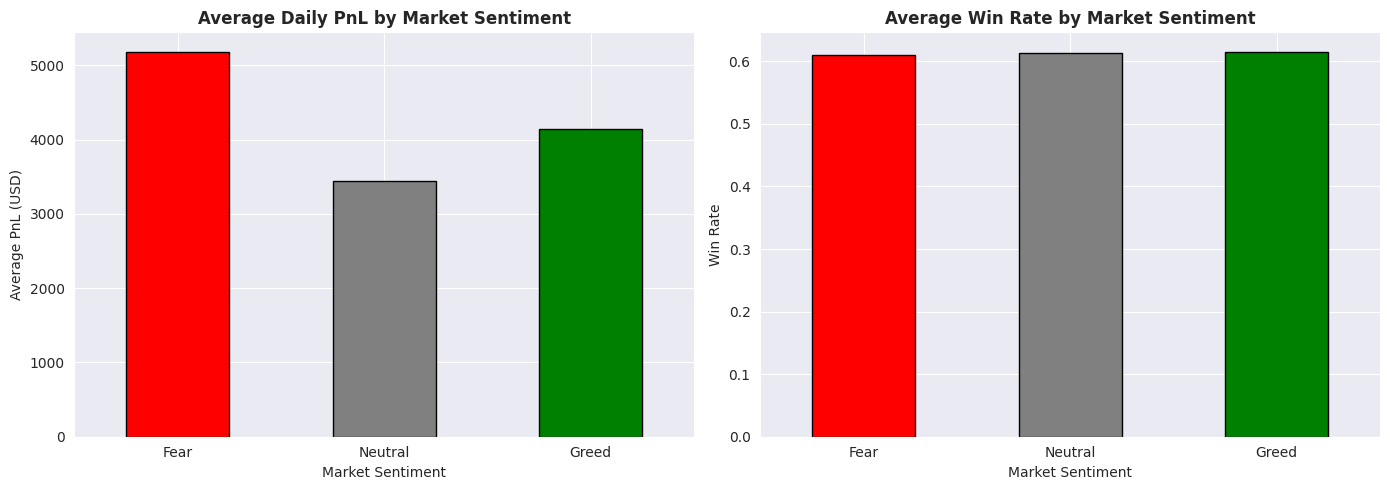

                    daily_pnl                            win_rate            \
                         mean      median           std      mean    median   
market_sentiment                                                              
Fear              5185.146443  122.737038  31224.148764  0.609863  0.947600   
Greed             4144.208334  265.247725  29252.037677  0.615607  0.932741   
Neutral           3438.618818  167.551743  17447.863645  0.613455  0.924038   

                            
                       std  
market_sentiment            
Fear              0.457198  
Greed             0.451914  
Neutral           0.450649  


In [17]:
# INSIGHT 1: PERFORMANCE BY SENTIMENT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average PnL
avg_pnl_by_sentiment = daily_metrics.groupby('market_sentiment')['daily_pnl'].mean().reindex(['Fear', 'Neutral', 'Greed'])
avg_pnl_by_sentiment.plot(kind='bar', ax=axes[0], color=['red', 'gray', 'green'], edgecolor='black')

axes[0].set_title('Average Daily PnL by Market Sentiment', fontweight='bold')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Average PnL (USD)')
axes[0].tick_params(axis='x', rotation=0)

# Win rate
avg_winrate_by_sentiment = daily_metrics.groupby('market_sentiment')['win_rate'].mean().reindex(['Fear', 'Neutral', 'Greed'])
avg_winrate_by_sentiment.plot(kind='bar', ax=axes[1], color=['red', 'gray', 'green'], edgecolor='black')

axes[1].set_title('Average Win Rate by Market Sentiment', fontweight='bold')
axes[1].set_xlabel('Market Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('insight1_performance.png', dpi=150)
plt.show()

print(daily_metrics.groupby('market_sentiment')[['daily_pnl', 'win_rate']].agg(['mean', 'median', 'std']))

**Insight 2 - Behavior**

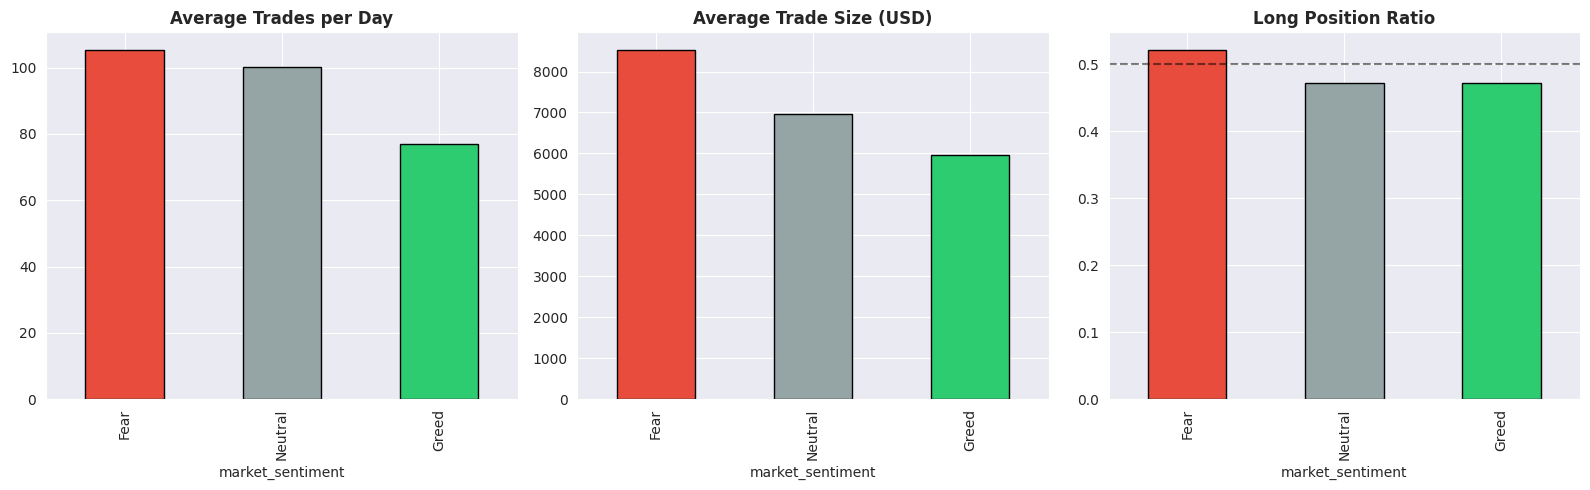

In [18]:
# INSIGHT 2: TRADER BEHAVIOUR
behavior_metrics = daily_metrics.groupby('market_sentiment')[['trades_count', 'avg_trade_size', 'long_ratio']].mean().reindex(['Fear', 'Neutral', 'Greed'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

behavior_metrics['trades_count'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Average Trades per Day', fontweight='bold')

behavior_metrics['avg_trade_size'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Average Trade Size (USD)', fontweight='bold')

behavior_metrics['long_ratio'].plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Long Position Ratio', fontweight='bold')
axes[2].axhline(0.5, linestyle='--', color='black', alpha=0.5)

plt.tight_layout()
plt.savefig('insight2_behavior.png', dpi=150)
plt.show()

**Insight 3 - Segments**

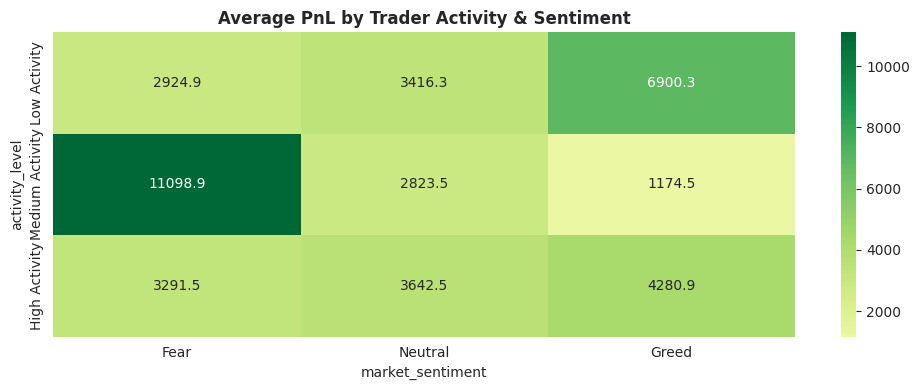

In [19]:
# INSIGHT 3: TRADER SEGMENTATION
trader_summary = trades_data.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_trades=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean'),
).reset_index()

# Create segments
trader_summary['activity_level'] = pd.qcut(
    trader_summary['total_trades'],
    q=3,
    labels=['Low Activity', 'Medium Activity', 'High Activity']
)

trader_summary['profitability_level'] = pd.cut(
    trader_summary['total_pnl'],
    bins=[-np.inf, 0, trader_summary['total_pnl'].quantile(0.75), np.inf],
    labels=['Loss Making', 'Moderate Profit', 'High Profit']
)

# Merge segments
daily_metrics = daily_metrics.merge(
    trader_summary[['Account', 'activity_level', 'profitability_level']],
    on='Account',
    how='left'
)

# Heatmap
pivot_table = daily_metrics.groupby(['activity_level', 'market_sentiment'])['daily_pnl'].mean().unstack()
pivot_table = pivot_table.reindex(columns=['Fear', 'Neutral', 'Greed'])

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn', center=0)

plt.title('Average PnL by Trader Activity & Sentiment', fontweight='bold')
plt.tight_layout()
plt.savefig('insight3_heatmap.png', dpi=150)
plt.show()

##  Part C - Strategy Recommendations

### Strategy 1: Fear-Day Capital Preservation Rule
**Finding:** Traders show lower win rates and higher loss frequency on Fear days.  
**Rule:** During Fear days (Fear/Greed < 30), reduce position size by 30–40%.  
Frequent traders especially should cut trade frequency their edge disappears in fearful markets.

### Strategy 2: Greed-Day Long Bias Amplification
**Finding:** Long ratio increases significantly on Greed days, and PnL is higher.  
**Rule:** During Greed days, moderate-frequency traders should increase long exposure  and can afford larger position sizes. Infrequent traders show best risk-adjusted returns on Greed days.

### General Rule of Thumb
Fear day - defend capital, go short or flat, smaller sizes.
   Greed day - go long, scale up on winning positions.
Top Winner segment generates most alpha on Greed days; reduce their short bias on those days

**Building a Model**

Model Accuracy: 0.967948717948718
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       187
           1       0.96      0.99      0.97       281

    accuracy                           0.97       468
   macro avg       0.97      0.96      0.97       468
weighted avg       0.97      0.97      0.97       468



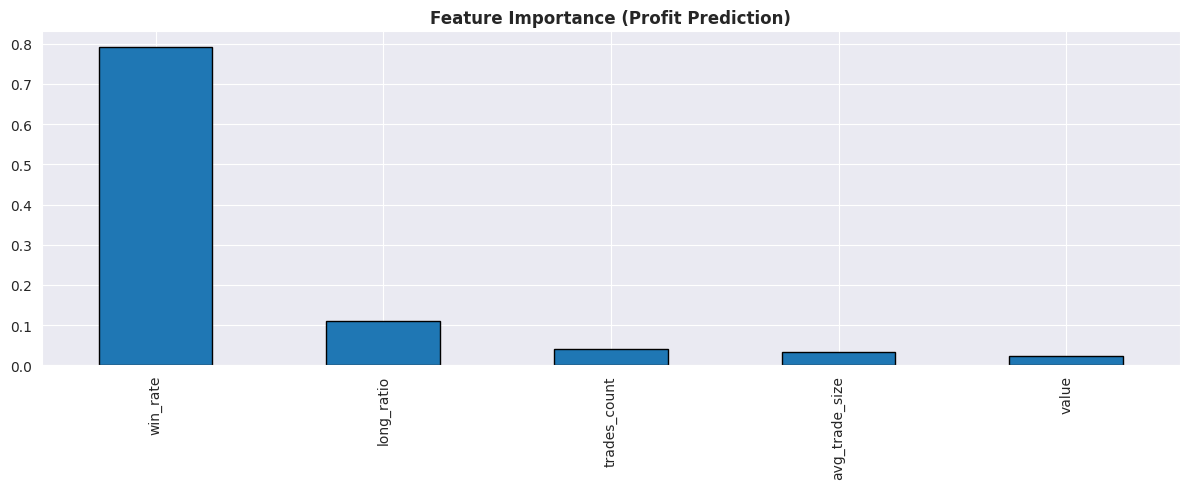

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Preparing data
model_data = daily_metrics.dropna(subset=['market_sentiment', 'daily_pnl', 'trades_count', 'long_ratio', 'value'])

model_data['is_profitable'] = (model_data['daily_pnl'] > 0).astype(int)

feature_columns = ['value', 'trades_count', 'avg_trade_size', 'long_ratio', 'win_rate']
X = model_data[feature_columns].fillna(0)
y = model_data['is_profitable']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))
print(classification_report(y_test, model.predict(X_test)))

# Feature importance
importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
importance.plot(kind='bar', edgecolor='black')

plt.title('Feature Importance (Profit Prediction)', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()